In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/References.txt
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/ReadThis.TXT
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/ReadThis/AKDEF.DOC
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/ReadThis/KDEF.DOC
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/ReadThis/ReadThis.rtf
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19ANHR.JPG
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19DIFL.JPG
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19AFHR.JPG
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19SUFR.JPG
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19HAFR.JPG
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19NES.JPG
/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF/BF19/BF19DIHR.JPG
/kaggle/input/datasets/navneet009

## Kdef Dataset Fau


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from skimage.feature import hog

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
kdef_path = "/kaggle/input/datasets/navneet0094/kdef-data/KDEF_and_AKDEF/KDEF"


In [3]:
emotion_map = {

    'AF':0,
    'AN':1,
    'DI':2,
    'HA':3,
    'NE':4,
    'SA':5,
    'SU':6
}

emotion_names = [

    'Afraid',
    'Angry',
    'Disgust',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

In [4]:
data = []
labels = []

for root, dirs, files in os.walk(kdef_path):

    for file in files:

        if file.lower().endswith(".jpg"):

            img_path = os.path.join(root, file)

            try:

                img = Image.open(img_path).convert('L')

                img = img.resize((128,128))

                img = np.array(img)

                # emotion code
                emotion = file[4:6]

                if emotion in emotion_map:

                    label = emotion_map[emotion]

                    data.append(img)

                    labels.append(label)

            except Exception as e:

                print("Error:", file, e)

data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

Data Shape: (4898, 128, 128)
Labels Shape: (4898,)


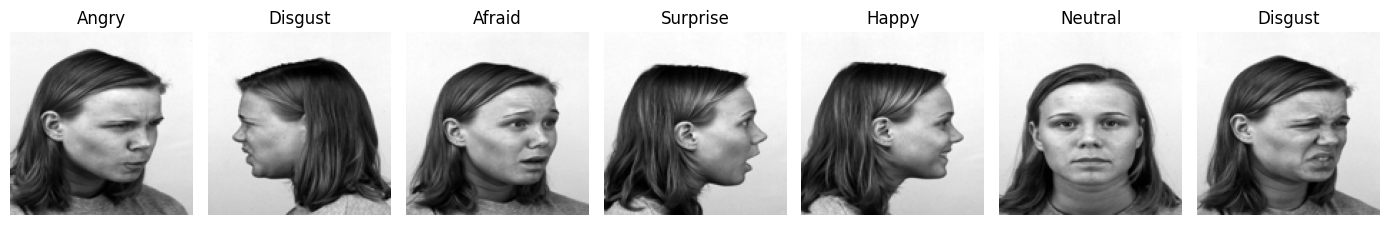

In [5]:
plt.figure(figsize=(14,4))

for i in range(7):

    plt.subplot(1,7,i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(emotion_names[labels[i]])

    plt.axis('off')

plt.tight_layout()

plt.show()

In [36]:
upper_faces = []
lower_faces = []

for img in data:

    # Upper Face
    upper = img[45:70, :]

    # Lower Face
    lower = img[82:107, :]

    upper_faces.append(upper)

    lower_faces.append(lower)

upper_faces = np.array(upper_faces)

lower_faces = np.array(lower_faces)

print("Upper Shape:", upper_faces.shape)

print("Lower Shape:", lower_faces.shape)

Upper Shape: (4898, 25, 128)
Lower Shape: (4898, 25, 128)


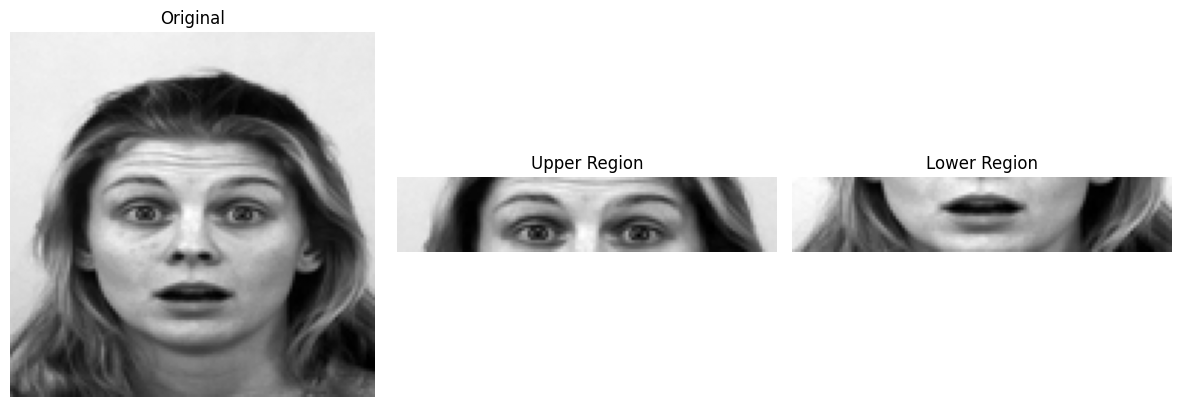

In [38]:
sample = 171

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(data[sample], cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(upper_faces[sample], cmap='gray')
ax[1].set_title("Upper Region")

ax[2].imshow(lower_faces[sample], cmap='gray')
ax[2].set_title("Lower Region")

for a in ax:
    a.axis('off')

plt.tight_layout()

plt.show()

In [39]:
def extract_hog_features(images):

    features = []

    for img in images:

        hog_features = hog(

            img,

            orientations=9,

            pixels_per_cell=(8,8),

            cells_per_block=(2,2),

            block_norm='L2-Hys'
        )

        features.append(hog_features)

    return np.array(features)

In [40]:
from skimage.feature import hog

In [41]:
X_original = extract_hog_features(data)
X_upper = extract_hog_features(upper_faces)
X_lower = extract_hog_features(lower_faces)
print("Original:", X_original.shape)

print("Upper:", X_upper.shape)

print("Lower:", X_lower.shape)

Original: (4898, 8100)
Upper: (4898, 1080)
Lower: (4898, 1080)


In [42]:
XO_train, XO_test, y_train, y_test = train_test_split(

    X_original,
    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

XU_train, XU_test, _, _ = train_test_split(

    X_upper,
    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

XL_train, XL_test, _, _ = train_test_split(

    X_lower,
    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

In [43]:
scaler_O = StandardScaler()

XO_train = scaler_O.fit_transform(XO_train)

XO_test = scaler_O.transform(XO_test)

In [44]:
scaler_U = StandardScaler()

XU_train = scaler_U.fit_transform(XU_train)

XU_test = scaler_U.transform(XU_test)

In [45]:
scaler_L = StandardScaler()

XL_train = scaler_L.fit_transform(XL_train)

XL_test = scaler_L.transform(XL_test)

In [46]:
svm_original = SVC(kernel='linear')

svm_upper = SVC(kernel='linear')

svm_lower = SVC(kernel='linear')

In [47]:
svm_original.fit(XO_train, y_train)

svm_upper.fit(XU_train, y_train)

svm_lower.fit(XL_train, y_train)

SVC(kernel='linear')

In [48]:
pred_original = svm_original.predict(XO_test)

pred_upper = svm_upper.predict(XU_test)

pred_lower = svm_lower.predict(XL_test)

In [49]:
acc_original = accuracy_score(y_test, pred_original)

acc_upper = accuracy_score(y_test, pred_upper)

acc_lower = accuracy_score(y_test, pred_lower)

print("Original Accuracy:", acc_original)

print("Upper Accuracy:", acc_upper)

print("Lower Accuracy:", acc_lower)

Original Accuracy: 0.5918367346938775
Upper Accuracy: 0.34591836734693876
Lower Accuracy: 0.4142857142857143


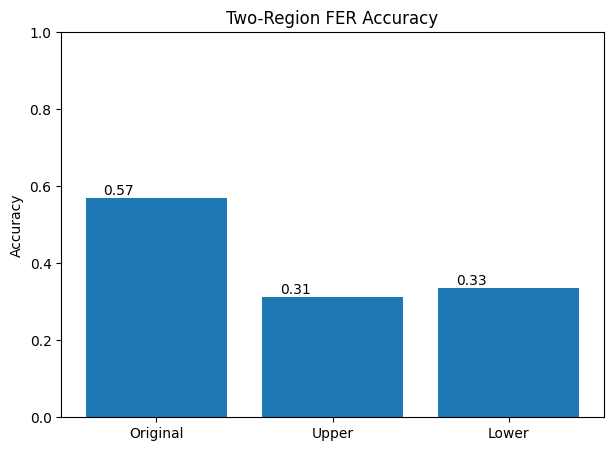

In [83]:
regions = [

    'Original',
    'Upper',
    'Lower'
]

accuracies = [

    acc_original,
    acc_upper,
    acc_lower
]

plt.figure(figsize=(7,5))

bars = plt.bar(

    regions,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Two-Region FER Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(

        bar.get_x() + 0.1,

        yval + 0.01,

        round(yval,2)
    )

plt.ylim(0,1)

plt.show()

In [84]:
print("\nORIGINAL FACE\n")

print(classification_report(
    y_test,
    pred_original
))


ORIGINAL FACE

              precision    recall  f1-score   support

           0       0.53      0.57      0.55       140
           1       0.63      0.64      0.64       140
           2       0.37      0.44      0.40       140
           3       0.79      0.70      0.74       140
           4       0.37      0.35      0.36       140
           5       0.70      0.66      0.68       140
           6       0.65      0.61      0.63       140

    accuracy                           0.57       980
   macro avg       0.58      0.57      0.57       980
weighted avg       0.58      0.57      0.57       980



In [85]:
print("\nUPPER FACE\n")

print(classification_report(
    y_test,
    pred_upper
))


UPPER FACE

              precision    recall  f1-score   support

           0       0.41      0.47      0.44       140
           1       0.29      0.34      0.31       140
           2       0.24      0.31      0.28       140
           3       0.25      0.28      0.26       140
           4       0.23      0.16      0.19       140
           5       0.47      0.40      0.43       140
           6       0.30      0.21      0.25       140

    accuracy                           0.31       980
   macro avg       0.31      0.31      0.31       980
weighted avg       0.31      0.31      0.31       980



In [86]:
print("\nLOWER FACE\n")

print(classification_report(
    y_test,
    pred_lower
))


LOWER FACE

              precision    recall  f1-score   support

           0       0.27      0.35      0.30       140
           1       0.31      0.40      0.35       140
           2       0.23      0.24      0.23       140
           3       0.61      0.58      0.60       140
           4       0.24      0.21      0.23       140
           5       0.45      0.31      0.37       140
           6       0.30      0.25      0.27       140

    accuracy                           0.33       980
   macro avg       0.35      0.33      0.34       980
weighted avg       0.35      0.33      0.34       980



In [87]:
report_upper = classification_report(

    y_test,
    pred_upper,

    output_dict=True
)

report_lower = classification_report(

    y_test,
    pred_lower,

    output_dict=True
)

emotion_analysis = []

for i, emotion in enumerate(emotion_names):

    upper_recall = report_upper[str(i)]['recall']

    lower_recall = report_lower[str(i)]['recall']

    if upper_recall > lower_recall:

        best_region = 'Upper'

    else:

        best_region = 'Lower'

    emotion_analysis.append([

        emotion,

        round(upper_recall,2),

        round(lower_recall,2),

        best_region
    ])

df_emotion = pd.DataFrame(

    emotion_analysis,

    columns=[

        'Emotion',

        'Upper Recall',

        'Lower Recall',

        'Best Region'
    ]
)

print(df_emotion)

    Emotion  Upper Recall  Lower Recall Best Region
0     Angry          0.47          0.35       Upper
1   Disgust          0.34          0.40       Lower
2      Fear          0.31          0.24       Upper
3     Happy          0.28          0.58       Lower
4       Sad          0.16          0.21       Lower
5  Surprise          0.40          0.31       Upper
6   Neutral          0.21          0.25       Lower


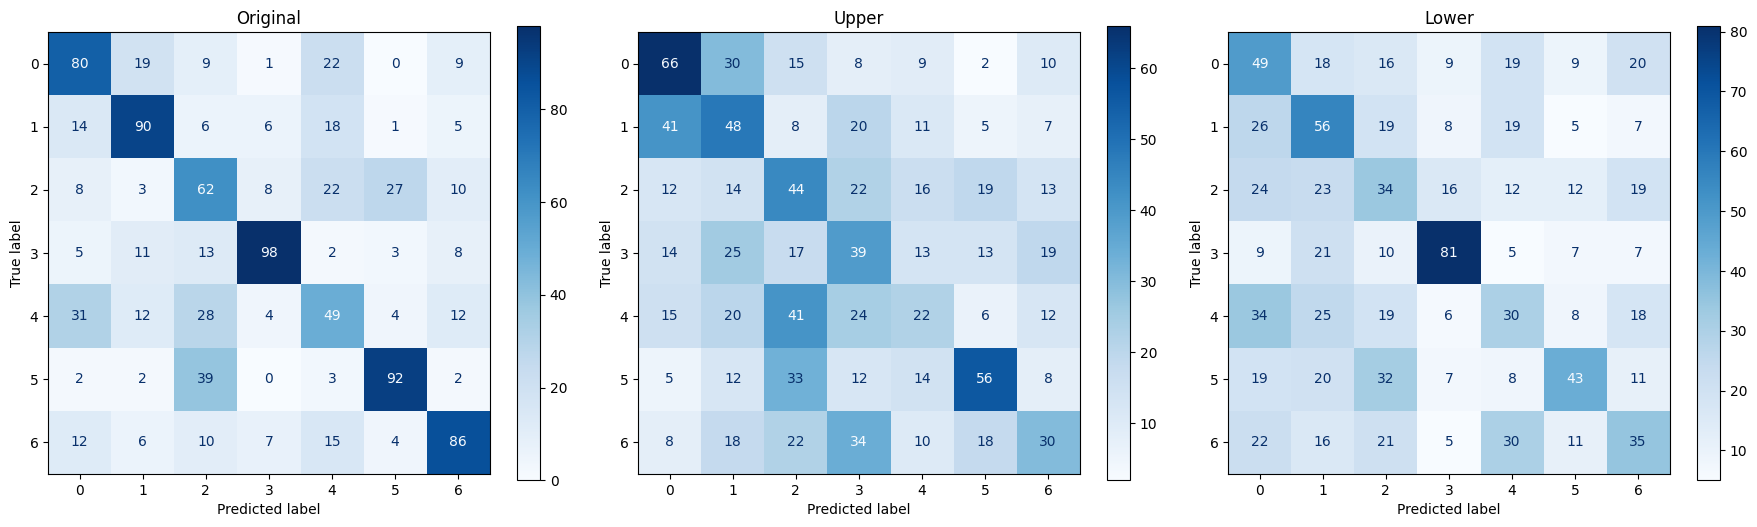

In [88]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Original
ConfusionMatrixDisplay.from_predictions(

    y_test,
    pred_original,

    ax=axes[0],

    cmap='Blues'
)

axes[0].set_title("Original")

# Upper
ConfusionMatrixDisplay.from_predictions(

    y_test,
    pred_upper,

    ax=axes[1],

    cmap='Blues'
)

axes[1].set_title("Upper")

# Lower
ConfusionMatrixDisplay.from_predictions(

    y_test,
    pred_lower,

    ax=axes[2],

    cmap='Blues'
)

axes[2].set_title("Lower")

plt.tight_layout()

plt.show()

## Fer-2013 Dataset Fau

In [50]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.utils import shuffle

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [51]:
csv_path = "/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv"

df = pd.read_csv(csv_path)

print(df.head())

   emotion     Usage                                             pixels
0        0  Training  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  Training  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  Training  231 212 156 164 174 138 161 173 182 200 106 38...
3        4  Training  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        6  Training  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [52]:
emotion_map = {

    'angry':0,
    'disgust':1,
    'fear':2,
    'happy':3,
    'neutral':4,
    'sad':5,
    'surprise':6
}

emotion_names = [

    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

In [53]:
from sklearn.utils import shuffle
data = []
labels = []

for i in range(len(df)):

    pixels = np.array(
        df.loc[i, ' pixels'].split(),
        dtype='uint8'
    )

    img = pixels.reshape(48,48)

    img = cv2.resize(
        img,
        (128,128)
    )

    label = df.loc[i, 'emotion']

    data.append(img)
    labels.append(label)

data = np.array(data)
labels = np.array(labels)

# Shuffle
data, labels = shuffle(
    data,
    labels,
    random_state=42
)

# Small subset for faster experiments
data = data[:5000]
labels = labels[:5000]

print(data.shape)

(5000, 128, 128)


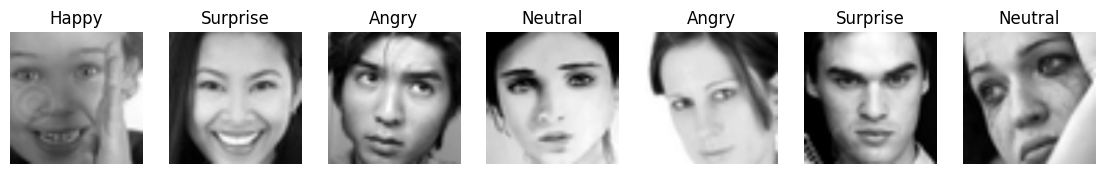

In [54]:
plt.figure(figsize=(14,4))

for i in range(7):

    plt.subplot(1,7,i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(
        emotion_names[labels[i]]
    )

    plt.axis('off')

plt.show()

In [63]:
upper_faces = []

lower_faces = []

for img in data:

    upper = img[23:63, :]

    lower = img[88:128, :]

    upper_faces.append(upper)

    lower_faces.append(lower)

upper_faces = np.array(
    upper_faces
)

lower_faces = np.array(
    lower_faces
)

print(
    upper_faces.shape
)

print(
    lower_faces.shape
)

(5000, 40, 128)
(5000, 40, 128)


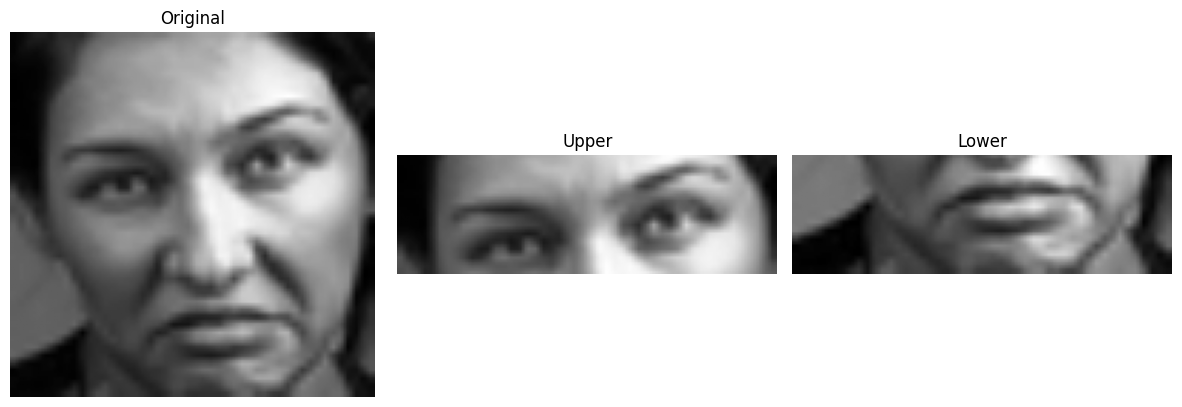

In [72]:
sample = 200
fig, ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(data[sample],cmap='gray')

ax[0].set_title("Original")

ax[1].imshow(upper_faces[sample],cmap='gray')

ax[1].set_title("Upper")

ax[2].imshow(lower_faces[sample],cmap='gray')

ax[2].set_title("Lower")

for a in ax:
    a.axis('off')

plt.tight_layout()

plt.show()

In [73]:
def extract_hog_features(images):

    features = []

    for img in images:

        hog_features = hog(

            img,

            orientations=9,

            pixels_per_cell=(8,8),

            cells_per_block=(2,2),

            block_norm='L2-Hys'
        )

        features.append(
            hog_features
        )

    return np.array(features)

In [74]:
X_original = extract_hog_features(data)
X_upper = extract_hog_features(upper_faces)

X_lower = extract_hog_features(lower_faces)

In [75]:
print("Original:", X_original.shape)

print("Upper:", X_upper.shape)

print("Lower:", X_lower.shape)

Original: (5000, 8100)
Upper: (5000, 2160)
Lower: (5000, 2160)


In [76]:
XO_train, XO_test, y_train, y_test = train_test_split(

    X_original,
    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

XU_train, XU_test, _, _ = train_test_split(

    X_upper,
    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

XL_train, XL_test, _, _ = train_test_split(

    X_lower,
    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

In [77]:
scaler_O = StandardScaler()

XO_train = scaler_O.fit_transform(XO_train)
XO_test = scaler_O.transform(XO_test)

scaler_U = StandardScaler()

XU_train = scaler_U.fit_transform(XU_train)
XU_test = scaler_U.transform(XU_test)

scaler_L = StandardScaler()

XL_train = scaler_L.fit_transform(XL_train)
XL_test = scaler_L.transform(XL_test)

In [78]:
svm_original = SVC(kernel='linear')

svm_upper = SVC(kernel='linear')

svm_lower = SVC(kernel='linear')

svm_original.fit(XO_train, y_train)

svm_upper.fit(XU_train, y_train)

svm_lower.fit(XL_train, y_train)

SVC(kernel='linear')

In [79]:
pred_original = svm_original.predict(XO_test)

pred_upper = svm_upper.predict(XU_test)

pred_lower = svm_lower.predict(XL_test)

In [80]:
acc_original = accuracy_score(
    y_test,
    pred_original
)

acc_upper = accuracy_score(
    y_test,
    pred_upper
)

acc_lower = accuracy_score(
    y_test,
    pred_lower
)

print("Original:", acc_original)

print("Upper:", acc_upper)

print("Lower:", acc_lower)

Original: 0.374
Upper: 0.271
Lower: 0.302


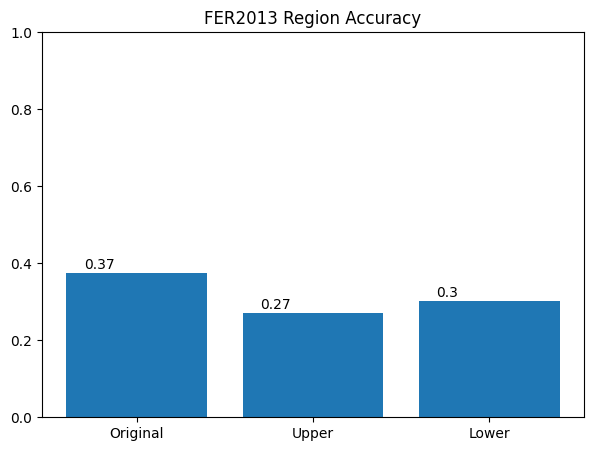

In [81]:
regions = ['Original', 'Upper', 'Lower']

accuracies = [
    acc_original,
    acc_upper,
    acc_lower
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    regions,
    accuracies
)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+0.1,
        yval+0.01,
        round(yval,2)
    )

plt.ylim(0,1)

plt.title("FER2013 Region Accuracy")

plt.show()

4
